# Lab for Week 2

## Implementation of Logicstic Regression

You will implement a Logistic regression by modifying/extending the Pytorch (compact) code of Linear regression, and apply it to two different datasets. 

Briefly, Logistic regression (or Logit regression) model is another class of regression models that is used to estimate the probability that a given instance of a dataset belongs to a particular class. You may think of a classic example of spam and non-spam emails. The idea is that if the estimated probality is greater than 50%, then the model predicts that the instance belongs to a positve class, say 'A', else it predicts that it belongs to negative class, B. This definition makes the Logistic regression model a binary classifier.

### Overview of the problem

Suppose that you are the administrator of a university department and you want to determine each applicant's chance of admission based on their results on two exams. You have historical data from previous applicants that you can use as a training set for logistic regression. For each training example, you have the applicant's scores on two exams and the admissions decision.

Your task is to build a classification model that estimates an applicant's probability of admission based the scores from those two exams.

Therefore, you will build a logistic regression model to predict whether a student gets admitted into a university.

In [12]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

### Load the admissions data

We start by loading the admissions dataset into tensors.

In [13]:
data_path = "ex2data1.txt"
raw_data = np.loadtxt(data_path, delimiter=",")

features = torch.tensor(raw_data[:, :2], dtype=torch.float32)
labels = torch.tensor(raw_data[:, -1], dtype=torch.float32).reshape(-1, 1)

print("using data file:", data_path)
print("features shape:", features.shape)
print("labels shape:", labels.shape)
print("first sample:", features[0], "label:", labels[0].item())

using data file: ex2data1.txt
features shape: torch.Size([100, 2])
labels shape: torch.Size([100, 1])
first sample: tensor([34.6237, 78.0247]) label: 0.0


#### Load the admissions data
- `np.loadtxt(...)` reads the comma-separated file into a NumPy array.
- The first two columns become the input features, and the last column becomes the binary label.
- We reshape the labels to `(N, 1)` so they match the model output shape.

### Visualise the class labels

Before training, let us plot the admitted and non-admitted examples to see how the classes are distributed.

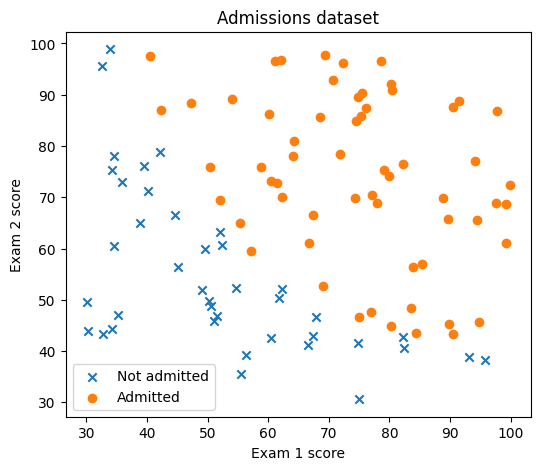

In [14]:
labels_np = labels.squeeze().numpy()
not_admitted = labels_np == 0
admitted = labels_np == 1

plt.figure(figsize=(6, 5))
plt.scatter(raw_data[not_admitted, 0], raw_data[not_admitted, 1], label="Not admitted", marker="x")
plt.scatter(raw_data[admitted, 0], raw_data[admitted, 1], label="Admitted", marker="o")
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("Admissions dataset")
plt.legend()
plt.show()

#### Visualise the class labels
- The scatter plot lets us inspect the two classes before we fit a model.
- A binary classification problem becomes easier to reason about once we can see where the labels sit in feature space.

### Standardise the input features

The two exam scores are on the same general scale, but standardising them helps SGD train more smoothly.

In [15]:
feature_mean = features.mean(dim=0, keepdim=True)
feature_std = features.std(dim=0, keepdim=True)
features_standardised = (features - feature_mean) / feature_std

print("feature mean:", feature_mean)
print("feature std:", feature_std)
print("features shape:", features[0])
print("first standardised sample:", features_standardised[0])

feature mean: tensor([[65.6443, 66.2220]])
feature std: tensor([[19.4582, 18.5828]])
features shape: tensor([34.6237, 78.0247])
first standardised sample: tensor([-1.5942,  0.6351])


#### Standardise the input features
- Standardisation shifts each feature to mean `0` and scales it to standard deviation `1`.
- We keep `feature_mean` and `feature_std` because we need the same transformation for new inputs and the decision-boundary grid.

### Prepare mini-batches

We now package the data into mini-batches

In [16]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = TensorDataset(*data_arrays)
    return DataLoader(dataset, batch_size=batch_size, shuffle=is_train)


batch_size = 16
data_iter = load_array((features_standardised, labels), batch_size)

first_batch_features, first_batch_labels = next(iter(data_iter))
print("batch feature shape:", first_batch_features.shape)
print("batch label shape:", first_batch_labels.shape)

batch feature shape: torch.Size([16, 2])
batch label shape: torch.Size([16, 1])


#### Prepare mini-batches
- `TensorDataset` keeps the features and labels paired together.
- `DataLoader` gives us shuffled mini-batches so the optimiser updates the model a little at a time.

### Build the compact logistic regression model

For logistic regression, the linear layer still produces the score, and the sigmoid-based loss handles the binary classification objective.

In [17]:
net = nn.Sequential(nn.Linear(2, 1, bias=True))
loss_fn = nn.BCELoss()
optimiser = torch.optim.SGD(net.parameters(), lr=0.1)

print(net)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
)


#### Build the compact logistic regression model
- `nn.Linear(2, 1)` learns one score from the two exam features.
- `nn.BCELoss()` binary cross-entropy loss

### Train the logistic regression model

The training loop is almost identical to the compact week 2 linear regression example.

In [18]:
num_epochs = 400
checkpoint_epochs = {1, 50, 100, 200, 400}
loss_history = []

for epoch in range(num_epochs):
    net.train()
    for X, y in data_iter:
        optimiser.zero_grad()
        logits = net(X)
        probabilities = torch.sigmoid(logits)
        loss = loss_fn(probabilities, y)
        loss.backward() # compute the gradient of the loss with respect to the model parameters
        optimiser.step() # update the model parameters

    if epoch + 1 in checkpoint_epochs:
        net.eval()
        with torch.no_grad():
            probabilities = torch.sigmoid(net(features_standardised))
            epoch_loss = loss_fn(probabilities, labels).item()
        loss_history.append((epoch + 1, epoch_loss))
        print(f"epoch {epoch + 1}: loss {epoch_loss:.4f}")

epoch 1: loss 0.6498
epoch 50: loss 0.2366
epoch 100: loss 0.2166
epoch 200: loss 0.2068
epoch 400: loss 0.2040


#### Train the logistic regression model
- Each mini-batch goes through the same sequence: predict, measure loss, backpropagate, and update.
- The checkpoint prints let us confirm that the loss is moving in the right direction over time.

### Evaluate training accuracy

After training, we convert the logits into probabilities and then into binary class predictions.

In [19]:
net.eval()
with torch.no_grad():
    logits = net(features_standardised)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    accuracy = (predictions == labels).float().mean()

print(f"training accuracy: {accuracy.item():.2%}")

training accuracy: 90.00%


#### Evaluate training accuracy
- `torch.sigmoid` turns the model scores into probabilities between `0` and `1`.
- Thresholding at `0.5` gives us the predicted class for each training example.
- Accuracy tells us how many training labels the model classified correctly.

### Estimate admission probability for a new applicant

Now we can use the trained model to estimate the admission probability for a new set of exam scores.

In [20]:
new_student = torch.tensor([[45.0, 85.0]])
new_student_standardised = (new_student - feature_mean) / feature_std

with torch.no_grad():
    admission_probability = torch.sigmoid(net(new_student_standardised)).item()

print(f"Predicted admission probability for scores [45, 85]: {admission_probability:.4f}")

Predicted admission probability for scores [45, 85]: 0.7481


#### Estimate admission probability
- We must standardise the new exam scores with the same training-set mean and standard deviation.
- The output is a probability, so values closer to `1` indicate a stronger admission prediction.

### Plot the decision boundary

Finally, let us visualise the boundary where the model changes from predicting one class to the other.

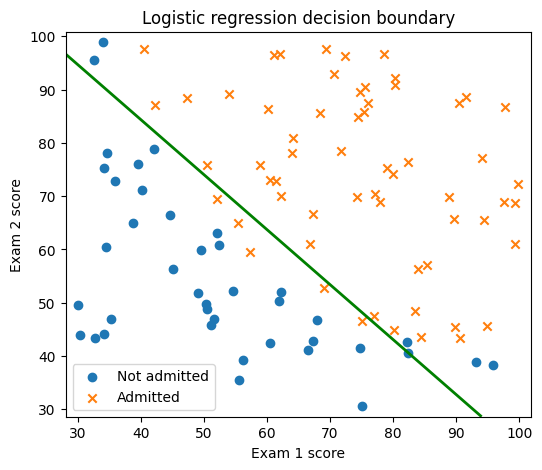

In [21]:
x1_min, x1_max = raw_data[:, 0].min() - 2, raw_data[:, 0].max() + 2
x2_min, x2_max = raw_data[:, 1].min() - 2, raw_data[:, 1].max() + 2
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200),
)
grid_points = torch.tensor(np.c_[x1_grid.ravel(), x2_grid.ravel()], dtype=torch.float32)
grid_points_standardised = (grid_points - feature_mean) / feature_std

with torch.no_grad():
    grid_probabilities = torch.sigmoid(net(grid_points_standardised)).reshape(x1_grid.shape).numpy()

plt.figure(figsize=(6, 5))
plt.scatter(raw_data[not_admitted, 0], raw_data[not_admitted, 1], label="Not admitted", marker="o")
plt.scatter(raw_data[admitted, 0], raw_data[admitted, 1], label="Admitted", marker="x")
plt.contour(x1_grid, x2_grid, grid_probabilities, levels=[0.5], colors="green", linewidths=2)
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("Logistic regression decision boundary")
plt.legend()
plt.show()

#### Plot the decision boundary
- We evaluate the model on a dense grid of points that covers the full exam-score range.
- The contour at probability `0.5` marks the boundary between the two predicted classes.